# Structured pruning of ALMA-7B: pilot results

Runs of 29 September 2026 on Snellius. Every system is ALMA-7B with 20% or 50% of its
attention heads and FFN channels removed, evaluated without any fine-tuning after pruning.

- **Test data:** the first 300 segments of each of the ten WMT22 directions (English to
  and from cs, de, is, ru, zh; Icelandic is WMT21), 3,000 segments per system, greedy decoding.
  The first 300 are not a random sample, so absolute scores are not comparable with
  published WMT22 numbers; comparisons between systems are.
- **Metrics:** BLEU and chrF++ (sacreBLEU), COMET (`Unbabel/wmt22-comet-da`), macro-averaged
  over directions. Significance is a paired bootstrap against the dense model (1,000 resamples).
- **Calibration:** segments from ALMA's human-written parallel data, 128 per direction unless
  stated otherwise.

The numbers come from the run reports in `results/pilot-2026-09-29/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

DATA = Path("../results/pilot-2026-09-29")
DIRECTIONS = [
    "cs-en",
    "de-en",
    "is-en",
    "ru-en",
    "zh-en",
    "en-cs",
    "en-de",
    "en-is",
    "en-ru",
    "en-zh",
]
INTO_EN, OUT_OF_EN = DIRECTIONS[:5], DIRECTIONS[5:]

INK, MUTED, GRID, BASE = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, AQUA, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#b5b3ab"
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "figure.facecolor": "#fcfcfb",
        "axes.facecolor": "#fcfcfb",
        "axes.edgecolor": BASE,
        "axes.labelcolor": INK,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "font.size": 9.5,
        "legend.frameon": False,
    }
)


def short(name):
    return name.removeprefix("alma-7b-") if name != "alma-7b" else "dense"


systems = pd.read_csv(DATA / "systems.csv")
bleu = pd.read_csv(DATA / "bleu_by_direction.csv", index_col="system")
comet = pd.read_csv(DATA / "comet_by_direction.csv", index_col="system")
widths = pd.read_csv(DATA / "layer_widths.csv")
overlap = pd.read_csv(DATA / "overlap.csv")
bench = pd.read_csv(DATA / "bench.csv")

## All systems

SlimGPT with a global budget unless the name says otherwise. *Length ratio* is hypothesis over
reference length; *truncated* is the share of outputs that hit the 256-token limit.

In [2]:
table = systems.assign(system=systems.system.map(short)).rename(
    columns={
        "sparsity": "removed",
        "bleu": "BLEU",
        "chrf": "chrF++",
        "comet": "COMET",
        "length_ratio": "length ratio",
        "truncated_pct": "truncated %",
    }
)
table["removed"] = (table["removed"] * 100).astype(int).astype(str) + "%"
table.style.hide(axis="index").format(
    {
        "BLEU": "{:.2f}",
        "chrF++": "{:.2f}",
        "COMET": "{:.4f}",
        "length ratio": "{:.2f}",
        "truncated %": "{:.1f}",
    }
).background_gradient(
    subset=["COMET"], cmap=LinearSegmentedColormap.from_list("b", ["#fcfcfb", "#86b6ef"])
)

system,removed,calibration,BLEU,chrF++,COMET,length ratio,truncated %
dense,0%,nan,30.35,51.14,0.8474,0.96,0.0
slimgpt20-multi,20%,"1,280 prompts",20.65,41.71,0.8148,0.91,0.1
slimgpt20-multi-uniform,20%,"1,280 prompts",23.01,43.81,0.8222,0.89,0.0
slimgpt20-multi-log,20%,"1,280 prompts",21.92,42.92,0.8223,0.90,0.1
slimgpt20-multi-target,20%,"1,280 prompt+ref",28.33,49.33,0.8367,0.95,0.0
slimgpt20-multi-256,20%,"2,560 prompts",21.22,42.28,0.8195,0.90,0.2
slimgpt20-cs,20%,"256 prompts, cs",12.28,31.73,0.6845,0.96,2.1
slimgpt20-de,20%,"256 prompts, de",10.37,29.08,0.6482,1.00,1.8
slimgpt20-is,20%,"256 prompts, is",13.05,33.36,0.7105,0.97,1.3
slimgpt20-ru,20%,"256 prompts, ru",10.86,30.18,0.6523,0.95,0.6


Every pruned system is significantly below dense (p < 0.05) in every direction on every metric,
with five exceptions, all for `slimgpt20-multi-target`. At 50% no system is usable.

## Calibrating on the reference translation

By default the pruning criteria read only the prompt (instruction and source sentence), so the
network is never observed while it writes a translation. `-target` appends the reference
translation to each calibration prompt, the way ALMA's training data is formatted. It sees about
1.7 times as many calibration tokens, so `-256` is the control: prompts only, twice the segments
(156k tokens against 134k for `-target`).

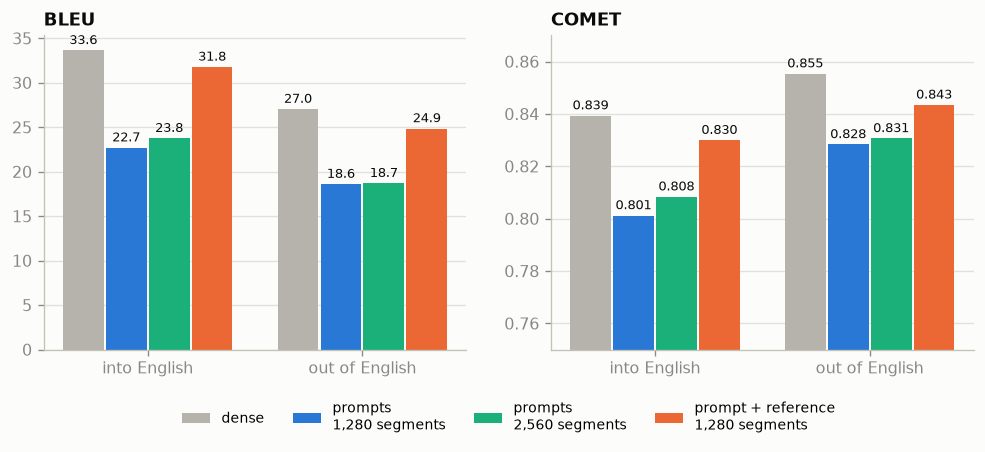

In [3]:
rows = [
    "alma-7b",
    "alma-7b-slimgpt20-multi",
    "alma-7b-slimgpt20-multi-256",
    "alma-7b-slimgpt20-multi-target",
]
labels = [
    "dense",
    "prompts\n1,280 segments",
    "prompts\n2,560 segments",
    "prompt + reference\n1,280 segments",
]
colors = [GRAY, BLUE, AQUA, ORANGE]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, (metric, frame, fmt) in zip(
    axes, [("BLEU", bleu, "{:.1f}"), ("COMET", comet, "{:.3f}")], strict=False
):
    x = np.arange(2)
    for i, (row, label, color) in enumerate(zip(rows, labels, colors, strict=False)):
        values = [frame.loc[row, INTO_EN].mean(), frame.loc[row, OUT_OF_EN].mean()]
        bars = ax.bar(x + (i - 1.5) * 0.2, values, width=0.19, color=color, label=label)
        ax.bar_label(bars, [fmt.format(v) for v in values], fontsize=7.5, color=INK, padding=2)
    ax.set_xticks(x, ["into English", "out of English"])
    ax.set_title(metric)
    ax.grid(axis="x", visible=False)
axes[1].set_ylim(0.75, 0.87)
axes[0].legend(loc="upper center", bbox_to_anchor=(1.1, -0.12), ncol=4, fontsize=8.5)
plt.show()

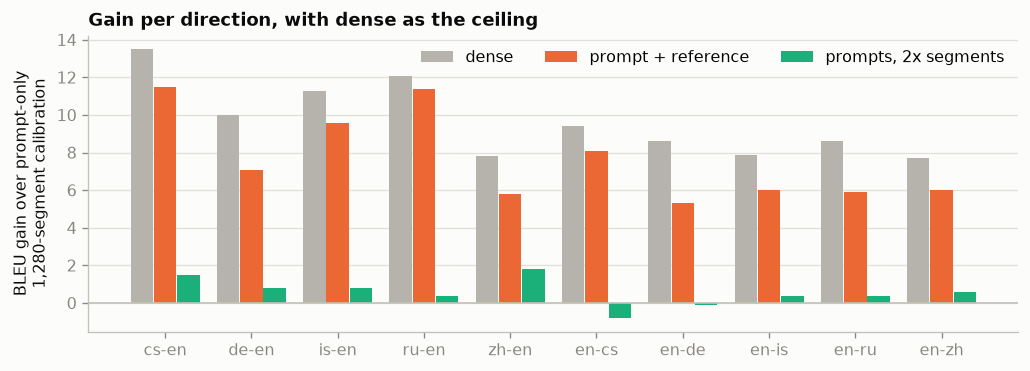

In [4]:
multi = "alma-7b-slimgpt20-multi"
delta = pd.DataFrame(
    {
        "prompt + reference": bleu.loc["alma-7b-slimgpt20-multi-target"] - bleu.loc[multi],
        "prompts, 2x segments": bleu.loc["alma-7b-slimgpt20-multi-256"] - bleu.loc[multi],
        "dense": bleu.loc["alma-7b"] - bleu.loc[multi],
    }
)[["dense", "prompt + reference", "prompts, 2x segments"]]

fig, ax = plt.subplots(figsize=(10, 3.2))
x = np.arange(len(DIRECTIONS))
for i, (column, color) in enumerate(zip(delta.columns, [GRAY, ORANGE, AQUA], strict=False)):
    ax.bar(x + (i - 1) * 0.27, delta[column], width=0.26, color=color, label=column)
ax.axhline(0, color=BASE, linewidth=1)
ax.set_xticks(x, DIRECTIONS)
ax.set_ylabel("BLEU gain over prompt-only\n1,280-segment calibration")
ax.set_title("Gain per direction, with dense as the ceiling")
ax.grid(axis="x", visible=False)
ax.legend(ncol=3, loc="upper right")
plt.show()

Calibrating on the reference recovers 79% of the BLEU and 67% of the COMET lost to pruning
(COMET +0.0219 over prompt-only, 95% CI [+0.0195, +0.0245]). The control gains +0.0047 COMET,
so the effect comes from the target side, not from the amount of calibration data. The gain is
larger into English than out of it; the hypothesis that it would mainly help out-of-English
directions does not hold. It also selects different units: its attention heads overlap 0.853
(Jaccard) with the prompt-only selection, against 0.988 for the control.

## How many units each layer loses

The criterion ranks units within a layer; a budget decides how many each layer gives up.
*Global* standardises scores per layer and cuts the lowest 20% across the whole model.
*Uniform* removes 20% from every layer. *Log-increase* is SlimGPT's schedule: nothing from
layer 0, rising logarithmically to 27% in layer 31.

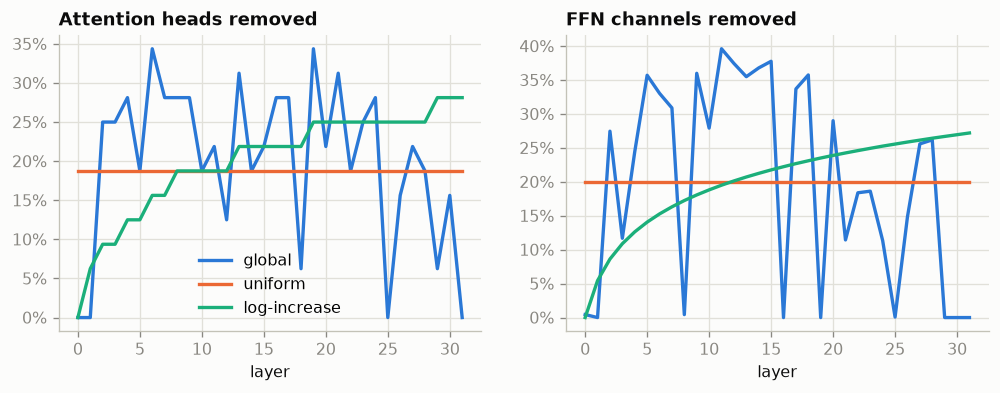

In [5]:
budgets = {
    "global": "alma-7b-slimgpt20-multi",
    "uniform": "alma-7b-slimgpt20-multi-uniform",
    "log-increase": "alma-7b-slimgpt20-multi-log",
}
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharex=True)
for (label, name), color in zip(budgets.items(), [BLUE, ORANGE, AQUA], strict=False):
    rows = widths[widths.system == name].sort_values("layer")
    axes[0].plot(rows.layer, 1 - rows.heads_kept / rows.heads_total, color=color, lw=2, label=label)
    axes[1].plot(
        rows.layer, 1 - rows.channels_kept / rows.channels_total, color=color, lw=2, label=label
    )
axes[0].set_title("Attention heads removed")
axes[1].set_title("FFN channels removed")
for ax in axes:
    ax.set_xlabel("layer")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[0].legend()
plt.show()

In [6]:
rows = ["alma-7b-slimgpt20-multi", "alma-7b-slimgpt20-multi-uniform", "alma-7b-slimgpt20-multi-log"]
pd.DataFrame(
    {
        "budget": ["global", "uniform", "log-increase"],
        "BLEU": systems.set_index("system").loc[rows, "bleu"].values,
        "COMET": systems.set_index("system").loc[rows, "comet"].values,
        "BLEU into en": bleu.loc[rows, INTO_EN].mean(axis=1).values,
        "BLEU out of en": bleu.loc[rows, OUT_OF_EN].mean(axis=1).values,
    }
).style.hide(axis="index").format(precision=2).format({"COMET": "{:.4f}"})

budget,BLEU,COMET,BLEU into en,BLEU out of en
global,20.650000,0.8148,22.700000,18.600000
uniform,23.010000,0.8222,25.100000,20.900000
log-increase,21.920000,0.8223,24.100000,19.740000


Both fixed schedules beat the global budget at 20% (COMET +0.0074 for uniform and +0.0076 for
log-increase, both p = 0.001), almost entirely into English. They tie with each other on COMET
(p = 0.88). The global budget swings from layer to layer, between nothing and 40% of a layer's
FFN channels, and leaves layers 0, 1 and the last three almost whole. Uniform removes 20% from
layer 0 as well and still beats it, so protecting the first layer is not what matters here;
avoiding very uneven cuts is. At 50% all three leave an unusable model, so they cannot be
ranked there.

## Pair-specific subnetworks

Each is calibrated on one language pair only (both directions, 256 segments) and evaluated on all
ten directions. Cells show COMET relative to the multi-directional subnetwork (1,280 segments,
all ten directions); outlined cells are the pair the subnetwork was calibrated on.

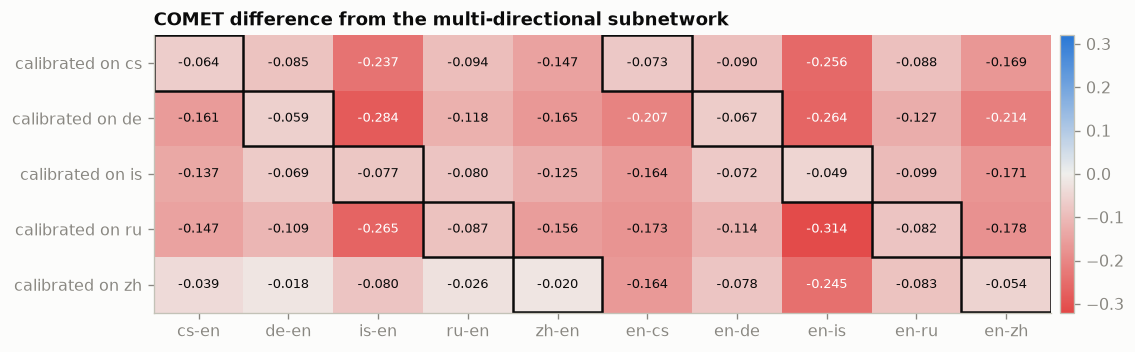

In [7]:
pairs = ["cs", "de", "is", "ru", "zh"]
matrix = pd.DataFrame(
    [comet.loc[f"alma-7b-slimgpt20-{p}"] - comet.loc[multi] for p in pairs],
    index=[f"calibrated on {p}" for p in pairs],
)[DIRECTIONS]
cmap = LinearSegmentedColormap.from_list("div", ["#e34948", "#f0efec", "#2a78d6"])
fig, ax = plt.subplots(figsize=(10, 3.0))
image = ax.imshow(
    matrix.values, cmap=cmap, norm=TwoSlopeNorm(vmin=-0.32, vcenter=0, vmax=0.32), aspect="auto"
)
for i, p in enumerate(pairs):
    for j, d in enumerate(DIRECTIONS):
        value = matrix.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value:+.3f}",
            ha="center",
            va="center",
            fontsize=7.5,
            color="white" if abs(value) > 0.2 else INK,
        )
        if p in d.split("-"):
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor=INK, lw=1.5))
ax.set_xticks(range(len(DIRECTIONS)), DIRECTIONS)
ax.set_yticks(range(len(pairs)), matrix.index)
ax.grid(False)
ax.set_title("COMET difference from the multi-directional subnetwork")
fig.colorbar(image, ax=ax, fraction=0.025, pad=0.01)
plt.show()

In [8]:
own = [
    comet.loc[f"alma-7b-slimgpt20-{p}", [f"{p}-en", f"en-{p}"]].mean()
    - comet.loc[multi, [f"{p}-en", f"en-{p}"]].mean()
    for p in pairs
]
other = [
    comet.loc[f"alma-7b-slimgpt20-{p}", [d for d in DIRECTIONS if p not in d]].mean()
    - comet.loc[multi, [d for d in DIRECTIONS if p not in d]].mean()
    for p in pairs
]
pd.DataFrame(
    {"calibrated on": pairs, "COMET change, own pair": own, "COMET change, other eight": other}
).style.hide(axis="index").format(precision=4)

calibrated on,"COMET change, own pair","COMET change, other eight"
cs,-0.0683,-0.1458
de,-0.0633,-0.1924
is,-0.0628,-0.1146
ru,-0.0846,-0.1820
zh,-0.0371,-0.0917


Every pair-specific subnetwork is worse than the multi-directional one, on its own pair as well,
and loses two to three times as much on the other directions: they are specialised. Directions
the calibration never saw suffer most, Icelandic above all (en-is BLEU 1.3 for the German
subnetwork). This comparison is confounded with calibration size, 256 against 1,280 segments.
SlimGPT fits a weight update to the calibration data, and 256 segments (about 16k tokens) barely
exceed the 11,008 dimensions of the FFN down-projection it solves for. FLAP, which fits nothing,
is unaffected by the same size difference (FLAP on German alone ties FLAP on all ten, p = 0.44).
A run at equal size (640 segments per direction for one pair) is needed to separate the two.

### Overlap between the kept units

Jaccard index of the kept FFN channels, in excess of what two random selections of the same
sizes would share (about 0.71 at this sparsity).

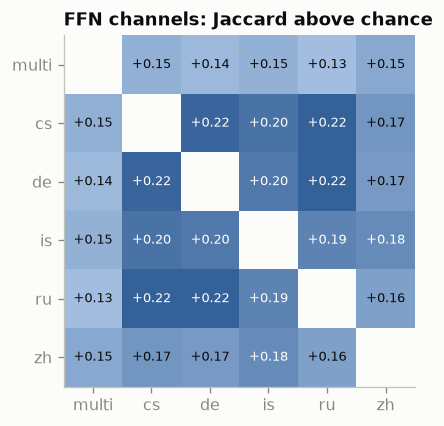

In [9]:
names = [multi] + [f"alma-7b-slimgpt20-{p}" for p in pairs]
ffn = overlap[overlap.component == "ffn_channels"]
excess = pd.DataFrame(np.nan, index=names, columns=names)
for _, row in ffn.iterrows():
    if row.left in names and row.right in names:
        excess.loc[row.left, row.right] = excess.loc[row.right, row.left] = row.excess_over_chance
labels = ["multi"] + pairs
fig, ax = plt.subplots(figsize=(4.6, 3.8))
masked = np.ma.masked_invalid(excess.values)
image = ax.imshow(
    masked, cmap=LinearSegmentedColormap.from_list("s", ["#cde2fb", "#104281"]), vmin=0.1, vmax=0.25
)
for i in range(len(names)):
    for j in range(len(names)):
        if i != j:
            v = excess.iloc[i, j]
            ax.text(
                j,
                i,
                f"{v:+.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if v > 0.18 else INK,
            )
ax.set_xticks(range(len(labels)), labels)
ax.set_yticks(range(len(labels)), labels)
ax.grid(False)
ax.set_title("FFN channels: Jaccard above chance")
plt.show()

The four European-language subnetworks resemble each other (+0.19 to +0.22) more than any of
them resembles the multi-directional one (+0.13 to +0.15), even though the multi calibration
contains all of their data. Chinese is the outlier. This fits the size explanation above as
much as a linguistic one.

## Criterion and sparsity

At 20% with multi-directional calibration SlimGPT beats FLAP by +1.6 BLEU (COMET +0.0116,
p = 0.001). At 50% both fail, differently: FLAP (pilot) did not stop generating (length ratio
3.6 to 4.2), SlimGPT writes short, fluent English that drops or invents content (length ratio
0.61 to 0.65).

In [10]:
rows = [
    "alma-7b-flap20-multi",
    "alma-7b-flap20-de",
    "alma-7b-slimgpt20-multi",
    "alma-7b-slimgpt50-multi",
    "alma-7b-slimgpt50-multi-log",
]
table.set_index("system").loc[
    [short(r) for r in rows], ["removed", "calibration", "BLEU", "chrF++", "COMET", "length ratio"]
].style.format({"BLEU": "{:.2f}", "chrF++": "{:.2f}", "COMET": "{:.4f}", "length ratio": "{:.2f}"})

,removed,calibration,BLEU,chrF++,COMET,length ratio
system,,,,,,
flap20-multi,20%,"1,280 prompts",19.02,38.22,0.8031,0.81
flap20-de,20%,"256 prompts, de",19.62,39.30,0.8043,0.86
slimgpt20-multi,20%,"1,280 prompts",20.65,41.71,0.8148,0.91
slimgpt50-multi,50%,"1,280 prompts",4.91,19.08,0.5567,0.65
slimgpt50-multi-log,50%,"1,280 prompts",3.82,17.26,0.5645,0.61


## Efficiency

One A100-40GB, exclusive node, 128 de-en segments with exactly 128 new tokens each, greedy,
median of three repeats.

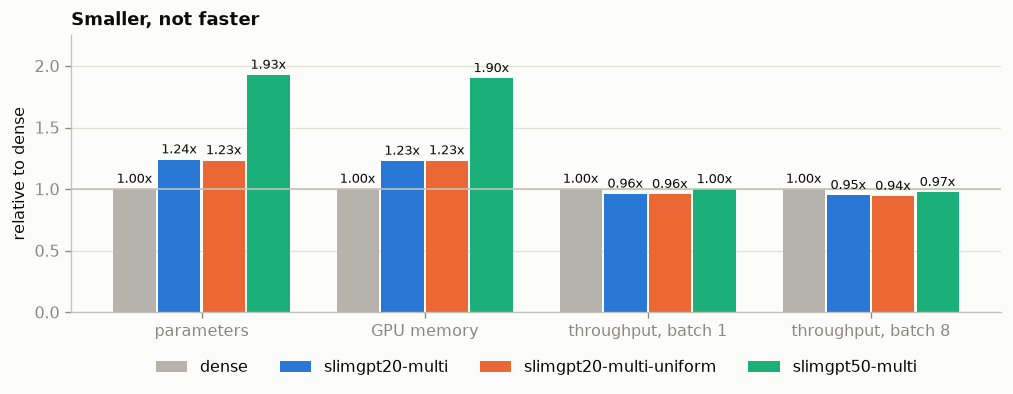

,params_b,resident_gib,peak_vram_b1_gib,tok_s_b1,tok_s_b8,first_token_ms
system,,,,,,
dense,6.74,12.55,12.68,38.1,239.6,29.3
slimgpt20-multi,5.44,10.22,10.34,36.6,227.5,30.7
slimgpt20-multi-uniform,5.47,10.19,10.30,36.5,225.9,30.8
slimgpt50-multi,3.50,6.61,6.69,38.0,233.4,30.5


In [11]:
b = bench.assign(system=bench.system.map(short)).set_index("system")
ratios = pd.DataFrame(
    {
        "parameters": b.params_b["dense"] / b.params_b,
        "GPU memory": b.resident_gib["dense"] / b.resident_gib,
        "throughput, batch 1": b.tok_s_b1 / b.tok_s_b1["dense"],
        "throughput, batch 8": b.tok_s_b8 / b.tok_s_b8["dense"],
    }
)
fig, ax = plt.subplots(figsize=(10, 3.0))
x = np.arange(len(ratios.columns))
for i, (name, color) in enumerate(zip(ratios.index, [GRAY, BLUE, ORANGE, AQUA], strict=False)):
    bars = ax.bar(x + (i - 1.5) * 0.2, ratios.loc[name], width=0.19, color=color, label=name)
    ax.bar_label(bars, [f"{v:.2f}x" for v in ratios.loc[name]], fontsize=7.5, color=INK, padding=2)
ax.axhline(1, color=BASE, linewidth=1)
ax.set_xticks(x, ratios.columns)
ax.set_ylabel("relative to dense")
ax.set_title("Smaller, not faster")
ax.set_ylim(0, 2.25)
ax.grid(axis="x", visible=False)
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.show()
b

Parameters shrink 1.24x at 20% and 1.93x at 50%, GPU memory 1.23x and 1.90x, but throughput
does not improve.
Hugging Face generation in eager mode is bound by per-step overhead here: model FLOP utilisation
is 0.2% at batch 1 and 1.6% at batch 8, so removing weights does not shorten a step. A speed
claim would need a leaner decoding loop (static KV cache and CUDA graphs).

## Not yet run

LoRA repair after pruning. The repair set (ALMA-Human-Parallel, 117,404 segments) contains two
segments whose source also appears in the WMT22 test set, and the contamination check stops on
any collision. Both are stock phrases outside the 300 segments evaluated here:

In [12]:
pd.read_csv(DATA / "repair_set_collisions.csv").style.hide(axis="index")

direction,train_record,source,train_target,test_segment,test_reference
en-cs,5463,Amazing.,Nádherný.,1356,Úžasné.
ru-en,614,Ну и что?,So what?,311,So what?
